# Paper explorations — a geometria das direções compartilhadas

Este notebook reúne os **9 experimentos** propostos para o paper sobre o
espectro θ da GSVD em espaços de word embeddings multilíngues (PT-BR × EN,
MUSE/fastText alinhados, 300d). O frame conjunto é o mesmo do
`demo_word_embeddings.ipynb`, encapsulado em `paper_common.py`: cada direção
da matriz `H` tem um ângulo θ ∈ [0°, 90°] — θ baixo = direção específica do
português, θ ≈ 45° = compartilhada, θ alto = específica do inglês.

Organização (os números dos experimentos seguem a proposta original):

| Seção | Experimentos | Pergunta |
|---|---|---|
| A | 1, 2, 3 | O que cada banda do espectro *sabe fazer*? (analogias, band-pass, retrieval) |
| B | 7, 8 | O que as direções *significam*? (coerência de tradução, entidades) |
| C | 4, 6, 9 | Generalização e controles (outras línguas, não-alinhado, diminutivos informais) |
| D | 5 | mBERT camada a camada |

Pré-requisitos: caches em `~/.gsvdlib/` (criados por `_fetch_muse.py` e
`_fetch_paper_data.py`) e o cache do mBERT (criado na primeira execução do
experimento 5). Resultados numéricos também ficam em `paper_results/*.json`.


# Seção A — Experimentos 1–3

# Experimentos 1–3: analogias cross-língue, band-pass funcional e direções centrais

Este script usa o frame GSVD conjunto PT/EN (ver `paper_common.py`). Cada
direção `i` de `H` tem um ângulo de alinhamento `angles[i]` em [15°, 70°]:
ângulos baixos indicam direções específicas do português, θ≈45° direções
compartilhadas pelas duas línguas, e ângulos altos direções específicas do
inglês. Testamos três hipóteses funcionais sobre esse espectro:

1. **Exp. 1** — offsets de analogia extraídos em PT transferem para EN, e
   transferem melhor quando concentram energia na banda compartilhada.
2. **Exp. 2** — identidade de língua vive nos extremos do espectro;
   semântica/tradução vive na banda compartilhada.
3. **Exp. 3** — o retrieval de tradução satura com poucas direções centrais,
   superando o mesmo número de direções aleatórias.

In [1]:
import json

import matplotlib

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from paper_common import Frame, RESULTS, nn_search

SEED = 1234
rng = np.random.default_rng(SEED)

f = Frame(seed=SEED)
print(f"Frame pronto: {len(f.pairs)} pares, {len(f.test_pairs)} test_pairs")
print(f"Ângulos: min={f.angles.min():.1f}°, max={f.angles.max():.1f}°")

Frame pronto: 8331 pares, 1000 test_pairs
Ângulos: min=15.1°, max=70.3°


## Experimento 1 — Transferência de analogias entre línguas

Datasets de relações curados manualmente (capital–país e
masculino–feminino) e gerados automaticamente (singular–plural, palavras
`w` frequentes tais que `w` e `w+"s"` estão no vocabulário). Cada par é
verificado contra o vocabulário; reportamos quantos sobram.

**Protocolo cross-língue**: para o par PT `(p_a, p_b)` formamos o offset
`r_pt = v_pt(p_a) − v_pt(p_b)`; para um par EN `(e_a, e_b)` da mesma
categoria, a consulta é `v_en(e_b) + r_pt` e a resposta correta é `e_a`
(ex.: `v_en(france) + [v_pt(paris) − v_pt(frança)] ≈ v_en(paris)`).
Busca por cosseno nos 20k vetores EN, excluindo `e_b`.

In [2]:
CAP_PT = [("paris", "frança"), ("londres", "inglaterra"), ("roma", "itália"),
          ("berlim", "alemanha"), ("lisboa", "portugal"), ("moscou", "rússia"),
          ("atenas", "grécia"), ("madrid", "espanha"), ("viena", "áustria"),
          ("dublin", "irlanda"), ("oslo", "noruega"), ("estocolmo", "suécia"),
          ("varsóvia", "polônia"), ("budapeste", "hungria"),
          ("praga", "tchecoslováquia"), ("cairo", "egito"),
          ("tóquio", "japão"), ("pequim", "china"), ("brasília", "brasil"),
          ("ottawa", "canadá")]
CAP_EN = [("paris", "france"), ("london", "england"), ("rome", "italy"),
          ("berlin", "germany"), ("lisbon", "portugal"), ("moscow", "russia"),
          ("athens", "greece"), ("madrid", "spain"), ("vienna", "austria"),
          ("dublin", "ireland"), ("oslo", "norway"), ("stockholm", "sweden"),
          ("warsaw", "poland"), ("budapest", "hungary"),
          ("prague", "czechoslovakia"), ("cairo", "egypt"),
          ("tokyo", "japan"), ("beijing", "china"), ("ottawa", "canada")]
GEN_PT = [("rei", "rainha"), ("homem", "mulher"), ("pai", "mãe"),
          ("ator", "atriz"), ("irmão", "irmã"), ("filho", "filha"),
          ("príncipe", "princesa"), ("tio", "tia"), ("avô", "avó"),
          ("menino", "menina")]
GEN_EN = [("king", "queen"), ("man", "woman"), ("father", "mother"),
          ("actor", "actress"), ("brother", "sister"), ("son", "daughter"),
          ("prince", "princess"), ("uncle", "aunt"),
          ("grandfather", "grandmother"), ("boy", "girl")]


def filter_pairs(pairs, idx):
    return [(a, b) for a, b in pairs if a in idx and b in idx]


def plural_pairs(idx, n=25):
    """Pares (plural, singular) — offset 'adicionar s' — mais frequentes."""
    cands = []
    for w, i in idx.items():
        if w.isalpha() and len(w) > 2 and w + "s" in idx:
            cands.append((i, (w + "s", w)))
    cands.sort()
    return [p for _, p in cands[:n]]


datasets = {
    "capital-pais": (filter_pairs(CAP_PT, f.pt_idx), filter_pairs(CAP_EN, f.en_idx)),
    "masc-fem": (filter_pairs(GEN_PT, f.pt_idx), filter_pairs(GEN_EN, f.en_idx)),
    "sing-plural": (plural_pairs(f.pt_idx), plural_pairs(f.en_idx)),
}
for cat, (ppt, pen) in datasets.items():
    print(f"{cat}: {len(ppt)} pares PT, {len(pen)} pares EN no vocab")

capital-pais: 20 pares PT, 19 pares EN no vocab
masc-fem: 10 pares PT, 10 pares EN no vocab
sing-plural: 25 pares PT, 25 pares EN no vocab


In [3]:
shared_mask = f.band_mask(40, 50)


def run_analogy(pt_pairs, en_pairs, max_combos=400, project_mask=None,
                seed=SEED):
    """Analogia cross-língue. Retorna lista de resultados por combinação.

    Cada item: (i_pt, hit1, hit5) onde i_pt indexa o offset PT usado.
    """
    r = np.random.default_rng(seed)
    combos = [(i, j) for i in range(len(pt_pairs))
              for j in range(len(en_pairs))
              if pt_pairs[i] != en_pairs[j]]
    if len(combos) > max_combos:
        combos = [combos[t] for t in r.choice(len(combos), max_combos,
                                              replace=False)]
    X_en = f.en_X
    offsets = {i: f.v_pt(a) - f.v_pt(b) for i, (a, b) in enumerate(pt_pairs)}
    if project_mask is not None:
        X_en = f.band_project(f.en_X, project_mask)
        offsets = {i: f.band_project(v.reshape(-1, 1), project_mask).ravel()
                   for i, v in offsets.items()}
    out = []
    for i, j in combos:
        e_a, e_b = en_pairs[j]
        q = (X_en[:, f.en_idx[e_b]] + offsets[i])
        top = nn_search(q, X_en, exclude={f.en_idx[e_b]}, k=5)
        gold = f.en_idx[e_a]
        out.append((i, int(top[0] == gold), int(gold in top)))
    return out


exp1 = {}
for cat, (ppt, pen) in datasets.items():
    res = run_analogy(ppt, pen)
    top1 = float(np.mean([h1 for _, h1, _ in res]))
    top5 = float(np.mean([h5 for _, _, h5 in res]))
    exp1[cat] = {"n_pt": len(ppt), "n_en": len(pen), "n_combos": len(res),
                 "top1": top1, "top5": top5, "_res": res, "_ppt": ppt}
    print(f"{cat}: top1={top1:.3f}, top5={top5:.3f} ({len(res)} combos)")

capital-pais: top1=0.711, top5=0.942 (380 combos)


masc-fem: top1=0.990, top5=1.000 (100 combos)


sing-plural: top1=0.282, top5=0.480 (400 combos)


### Energia na banda compartilhada × taxa de acerto do offset

Para cada offset PT `r_pt`, medimos a fração da sua energia (no frame H)
que cai na banda compartilhada 40°–50°, e correlacionamos (Pearson) com a
acurácia média top-1 das combinações que usam aquele offset. Também
reportamos as médias por quartil de energia.

In [4]:
band_energy_corr = {}
all_e, all_a = [], []
for cat, d in exp1.items():
    per_offset = {}
    for i, h1, _ in d["_res"]:
        per_offset.setdefault(i, []).append(h1)
    energies, accs = [], []
    for i, hits in sorted(per_offset.items()):
        p_a, p_b = d["_ppt"][i]
        r_pt = f.v_pt(p_a) - f.v_pt(p_b)
        e = float(f.energy_profile(r_pt)[shared_mask].sum())
        energies.append(e)
        accs.append(float(np.mean(hits)))
    energies, accs = np.array(energies), np.array(accs)
    all_e.append(energies)
    all_a.append(accs)
    if len(energies) > 2 and energies.std() > 0 and accs.std() > 0:
        pear = float(np.corrcoef(energies, accs)[0, 1])
    else:
        pear = None
    # quartis por energia
    order = np.argsort(energies)
    qs = np.array_split(order, 4)
    quart = [{"energia_media": float(energies[q].mean()),
              "acc_media": float(accs[q].mean())} for q in qs]
    band_energy_corr[cat] = {
        "pearson": pear, "quartis": quart,
        "energia_por_offset": energies.round(4).tolist(),
        "acc_por_offset": accs.round(4).tolist()}
    print(f"{cat}: pearson(energia_banda, acc)={pear}")
    for k, q in enumerate(quart):
        print(f"  Q{k+1}: energia={q['energia_media']:.3f} "
              f"acc={q['acc_media']:.3f}")

# correlação global (todas as categorias juntas)
Eg, Ag = np.concatenate(all_e), np.concatenate(all_a)
pear_global = float(np.corrcoef(Eg, Ag)[0, 1])
print(f"pearson global = {pear_global:.3f}")

exp1_out = {cat: {k: v for k, v in d.items() if not k.startswith("_")}
            for cat, d in exp1.items()}
exp1_out["banda_compartilhada_40_50"] = band_energy_corr
exp1_out["pearson_global"] = pear_global
with open(RESULTS / "exp1.json", "w", encoding="utf-8") as fh:
    json.dump(exp1_out, fh, ensure_ascii=False, indent=2)
print("salvo:", RESULTS / "exp1.json")

capital-pais: pearson(energia_banda, acc)=-0.4474430575661897
  Q1: energia=0.179 acc=0.758
  Q2: energia=0.214 acc=0.695
  Q3: energia=0.234 acc=0.779
  Q4: energia=0.267 acc=0.611
masc-fem: pearson(energia_banda, acc)=0.08021056499536221
  Q1: energia=0.177 acc=1.000
  Q2: energia=0.210 acc=0.967
  Q3: energia=0.229 acc=1.000
  Q4: energia=0.239 acc=1.000
sing-plural: pearson(energia_banda, acc)=-0.23423397807654198
  Q1: energia=0.188 acc=0.257
  Q2: energia=0.205 acc=0.336
  Q3: energia=0.232 acc=0.273
  Q4: energia=0.284 acc=0.274
pearson global = -0.216
salvo: C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp1.json


## Experimento 2 — Band-pass funcional

Quatro bandas: **PT-side** (θ<40°), **shared** (40°≤θ≤50°), **EN-side**
(θ>50°) e um **controle** com o mesmo número de direções da shared, mas
sorteadas ao acaso (semente fixa). Para cada banda avaliamos três tarefas
sobre vetores band-projetados:

1. **Identificação de língua** — regressão logística PT vs EN nas 2000
   palavras dos `test_pairs` (70/30);
2. **Retrieval de tradução** — P@1/P@5 do vetor PT projetado contra os
   1000 candidatos EN projetados (500 consultas);
3. **Analogia capital–país** — protocolo do Exp. 1 (200 combinações).

In [5]:
masks = {
    "pt_side": f.angles < 40,
    "shared": shared_mask,
    "en_side": f.angles > 50,
}
rng2 = np.random.default_rng(SEED)
rand_dirs = rng2.choice(300, int(shared_mask.sum()), replace=False)
ctrl = np.zeros(300, dtype=bool)
ctrl[rand_dirs] = True
masks["controle_aleatorio"] = ctrl
for name, m in masks.items():
    print(f"{name}: {int(m.sum())} direções")

# matrizes dos test_pairs (colunas alinhadas: i-ésimo PT traduz i-ésimo EN)
tp_en = [e for e, p in f.test_pairs]
tp_pt = [p for e, p in f.test_pairs]
PT_tp = f.pt_X[:, [f.pt_idx[w] for w in tp_pt]]
EN_tp = f.en_X[:, [f.en_idx[w] for w in tp_en]]

ret_idx = np.random.default_rng(SEED).choice(len(f.test_pairs), 500,
                                             replace=False)


def retrieval_p1p5(PTb, ENb, queries=ret_idx):
    """P@1/P@5: consulta PT projetada, candidatos = 1000 EN projetados."""
    ENn = ENb / np.maximum(np.linalg.norm(ENb, axis=0), 1e-12)
    hits1 = hits5 = 0
    for i in queries:
        q = PTb[:, i]
        q = q / max(np.linalg.norm(q), 1e-12)
        top = np.argsort(-(q @ ENn))[:5]
        hits1 += int(top[0] == i)
        hits5 += int(i in top)
    n = len(queries)
    return hits1 / n, hits5 / n


def language_id_acc(PTb, ENb):
    X = np.hstack([PTb, ENb]).T
    y = np.r_[np.zeros(PTb.shape[1]), np.ones(ENb.shape[1])]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3,
                                          random_state=SEED, stratify=y)
    clf = LogisticRegression(max_iter=5000).fit(Xtr, ytr)
    return float(clf.score(Xte, yte))


exp2 = {}
cap_pt, cap_en = datasets["capital-pais"]
for name, m in masks.items():
    PTb = f.band_project(PT_tp, m)
    ENb = f.band_project(EN_tp, m)
    lang = language_id_acc(PTb, ENb)
    p1, p5 = retrieval_p1p5(PTb, ENb)
    ana = run_analogy(cap_pt, cap_en, max_combos=200, project_mask=m)
    a1 = float(np.mean([h for _, h, _ in ana]))
    a5 = float(np.mean([h for _, _, h in ana]))
    exp2[name] = {"n_direcoes": int(m.sum()), "lang_id_acc": lang,
                  "trad_P1": p1, "trad_P5": p5,
                  "analogia_top1": a1, "analogia_top5": a5}
    print(f"{name:20s} lang={lang:.3f} P@1={p1:.3f} P@5={p5:.3f} "
          f"ana1={a1:.3f} ana5={a5:.3f}")

with open(RESULTS / "exp2.json", "w", encoding="utf-8") as fh:
    json.dump(exp2, fh, ensure_ascii=False, indent=2)
print("salvo:", RESULTS / "exp2.json")

pt_side: 123 direções
shared: 72 direções
en_side: 105 direções
controle_aleatorio: 72 direções


pt_side              lang=0.568 P@1=0.650 P@5=0.782 ana1=0.510 ana5=0.815


shared               lang=0.527 P@1=0.672 P@5=0.780 ana1=0.435 ana5=0.760


en_side              lang=0.513 P@1=0.576 P@5=0.720 ana1=0.585 ana5=0.865


controle_aleatorio   lang=0.552 P@1=0.558 P@5=0.712 ana1=0.370 ana5=0.700
salvo: C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp2.json


## Experimento 3 — Retrieval de tradução × número de direções centrais

Ordenamos as 300 direções por |θ−45°| crescente (mais "compartilhadas"
primeiro). Para cada `k`, mantemos as `k` mais centrais e medimos P@1/P@5
de tradução (protocolo do Exp. 2-ii). Baseline: `k` direções aleatórias,
média de 3 sementes.

In [6]:
central_order = np.argsort(np.abs(f.angles - 45.0))
ks = [10, 25, 50, 75, 100, 150, 200, 300]
exp3 = {"ks": ks, "central": [], "aleatorio": []}
for k in ks:
    m = np.zeros(300, dtype=bool)
    m[central_order[:k]] = True
    p1, p5 = retrieval_p1p5(f.band_project(PT_tp, m), f.band_project(EN_tp, m))
    exp3["central"].append({"k": k, "P1": p1, "P5": p5})
    r1s, r5s = [], []
    for s in range(3):
        rm = np.zeros(300, dtype=bool)
        rm[np.random.default_rng(SEED + s).choice(300, k, replace=False)] = True
        rp1, rp5 = retrieval_p1p5(f.band_project(PT_tp, rm),
                                  f.band_project(EN_tp, rm))
        r1s.append(rp1)
        r5s.append(rp5)
    exp3["aleatorio"].append({"k": k, "P1": float(np.mean(r1s)),
                              "P5": float(np.mean(r5s))})
    print(f"k={k:3d} central P@1={p1:.3f} P@5={p5:.3f} | "
          f"aleatório P@1={np.mean(r1s):.3f} P@5={np.mean(r5s):.3f}")

with open(RESULTS / "exp3.json", "w", encoding="utf-8") as fh:
    json.dump(exp3, fh, ensure_ascii=False, indent=2)
print("salvo:", RESULTS / "exp3.json")

k= 10 central P@1=0.050 P@5=0.130 | aleatório P@1=0.043 P@5=0.127


k= 25 central P@1=0.296 P@5=0.464 | aleatório P@1=0.217 P@5=0.381


k= 50 central P@1=0.532 P@5=0.708 | aleatório P@1=0.471 P@5=0.635


k= 75 central P@1=0.666 P@5=0.782 | aleatório P@1=0.573 P@5=0.715


k=100 central P@1=0.696 P@5=0.826 | aleatório P@1=0.650 P@5=0.780


k=150 central P@1=0.770 P@5=0.868 | aleatório P@1=0.747 P@5=0.855


k=200 central P@1=0.796 P@5=0.896 | aleatório P@1=0.777 P@5=0.893


k=300 central P@1=0.830 P@5=0.930 | aleatório P@1=0.830 P@5=0.930
salvo: C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp3.json


### Curva P@1 × k — direções centrais vs aleatórias

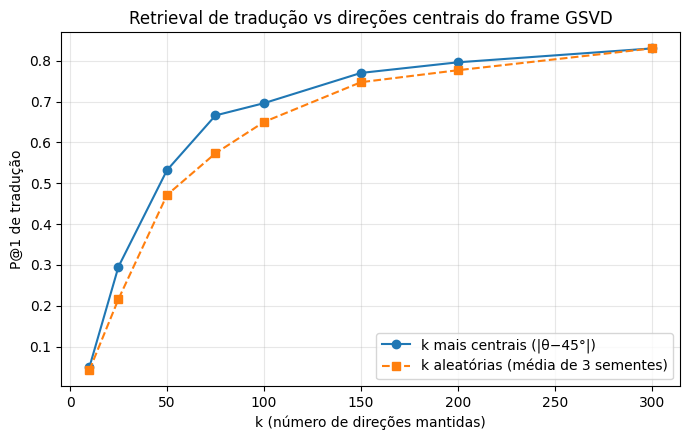

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, [d["P1"] for d in exp3["central"]], "o-",
        label="k mais centrais (|θ−45°|)")
ax.plot(ks, [d["P1"] for d in exp3["aleatorio"]], "s--",
        label="k aleatórias (média de 3 sementes)")
ax.set_xlabel("k (número de direções mantidas)")
ax.set_ylabel("P@1 de tradução")
ax.set_title("Retrieval de tradução vs direções centrais do frame GSVD")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

**Leitura esperada**: poucas direções centrais já recuperam quase todo o
desempenho de tradução, enquanto direções aleatórias precisam de muito
mais — evidência de que a semântica compartilhada se concentra na banda
central do espectro de alinhamento.

# Seção B — Experimentos 7–8

# Experimentos 7 e 8 — traduzibilidade do espectro e entidades nos extremos

Este script usa o frame GSVD conjunto PT/EN (ver `paper_common.py`). Cada
direção $i$ de $H$ tem um ângulo $\theta_i \in [15°, 70°]$: $\theta$ baixo =
específico do português, $\theta \approx 45°$ = compartilhado, $\theta$ alto =
específico do inglês.

- **Experimento 7:** mede a *coerência de tradução* de cada direção — quão
  bem as top palavras PT e EN alinhadas à direção se traduzem entre si. A
  hipótese é que a coerência tem pico na faixa compartilhada ($\theta$ perto
  de 45°) e cai nos extremos, i.e., o espectro ordena as direções por
  "traduzibilidade".
- **Experimento 8:** testa se os extremos do espectro codificam *entidades*
  (nomes próprios, cultura/corpus) em vez de vocabulário comum, usando como
  proxy de entidade as palavras que não aparecem no dicionário de tradução.

In [8]:
import json

import matplotlib

import matplotlib.pyplot as plt
import numpy as np

from paper_common import Frame, RESULTS

SEED = 20260819
f = Frame()
angles = f.angles
print(f"frame pronto: {len(angles)} direções, θ em "
      f"[{angles.min():.1f}°, {angles.max():.1f}°]")

frame pronto: 300 direções, θ em [15.1°, 70.3°]


## Experimento 7 — coerência de tradução por direção

Para cada direção $i$: pegamos as top-10 palavras PT e top-10 EN mais
alinhadas a $H_i$. A coerência é a média simétrica de duas frações:
(i) fração das palavras PT cujo conjunto de traduções (`pt2en`) intersecta o
top-10 EN; (ii) fração das EN cujo `en2pt` intersecta o top-10 PT.
Palavras fora do dicionário contam como não-coerentes.

In [9]:
K = 10
n_dir = f.g.H.shape[0]
coherence = np.zeros(n_dir)
tops = []
for i in range(n_dir):
    tp, te = f.top_words(f.g.H[i, :], K)
    te_set, tp_set = set(te), set(tp)
    frac_pt = np.mean([bool(f.pt2en.get(w, set()) & te_set) for w in tp])
    frac_en = np.mean([bool(f.en2pt.get(w, set()) & tp_set) for w in te])
    coherence[i] = 0.5 * (frac_pt + frac_en)
    tops.append((tp, te))
print(f"coerência média global: {coherence.mean():.3f}")

coerência média global: 0.185


### (a) Scatter coerência × θ com curva binned (bins de 5°)

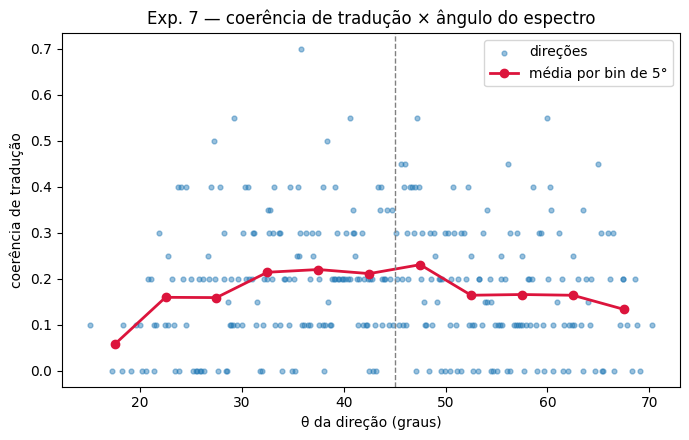

In [10]:
bin_edges = np.arange(15.0, 75.0, 5.0)
bin_centers, bin_means, bin_counts = [], [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    m = (angles >= lo) & (angles < hi)
    if m.sum() > 0:
        bin_centers.append(0.5 * (lo + hi))
        bin_means.append(float(coherence[m].mean()))
        bin_counts.append(int(m.sum()))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(angles, coherence, s=12, alpha=0.45, label="direções")
ax.plot(bin_centers, bin_means, "o-", color="crimson", lw=2,
        label="média por bin de 5°")
ax.axvline(45, color="gray", ls="--", lw=1)
ax.set_xlabel("θ da direção (graus)")
ax.set_ylabel("coerência de tradução")
ax.set_title("Exp. 7 — coerência de tradução × ângulo do espectro")
ax.legend()
fig.tight_layout()
fig.savefig("_paper_exp78_fig7.png", dpi=150)

### (b) Pico e médias por faixa; (c) correlação com −|θ−45°|

In [11]:
peak_j = int(np.argmax(bin_means))
low_m = angles < 30
mid_m = (angles >= 40) & (angles <= 50)
high_m = angles > 60
mean_low = float(coherence[low_m].mean()) if low_m.any() else None
mean_mid = float(coherence[mid_m].mean()) if mid_m.any() else None
mean_high = float(coherence[high_m].mean()) if high_m.any() else None
corr = float(np.corrcoef(coherence, -np.abs(angles - 45.0))[0, 1])

print(f"pico: bin centrado em {bin_centers[peak_j]:.1f}° "
      f"(coerência média {bin_means[peak_j]:.3f}, n={bin_counts[peak_j]})")
print(f"média θ<30°:   {mean_low:.3f}  (n={int(low_m.sum())})")
print(f"média 40–50°:  {mean_mid:.3f}  (n={int(mid_m.sum())})")
print(f"média θ>60°:   {mean_high:.3f}  (n={int(high_m.sum())})")
print(f"corr(coerência, −|θ−45°|) = {corr:.3f}")

pico: bin centrado em 47.5° (coerência média 0.231, n=36)
média θ<30°:   0.146  (n=56)
média 40–50°:  0.221  (n=72)
média θ>60°:   0.151  (n=41)
corr(coerência, −|θ−45°|) = 0.221


### (d) Exemplos qualitativos: 3 direções de alta e 3 de baixa coerência

In [12]:
order = np.argsort(-coherence)
examples = {"alta": [], "baixa": []}
for label, idxs in [("alta", order[:3]), ("baixa", order[-3:])]:
    print(f"\n=== coerência {label} ===")
    for i in idxs:
        tp, te = tops[i]
        print(f"dir {i:3d}  θ={angles[i]:5.1f}°  coerência={coherence[i]:.2f}")
        print(f"   PT: {', '.join(tp)}")
        print(f"   EN: {', '.join(te)}")
        examples[label].append({
            "direction": int(i), "theta": float(angles[i]),
            "coherence": float(coherence[i]), "top_pt": tp, "top_en": te})


=== coerência alta ===
dir  94  θ= 35.8°  coerência=0.70
   PT: humanista, catolicismo, princípios, protestantismo, ideologia, conservadora, politicamente, liberalismo, religião, marxismo
   EN: ideology, socialism, beliefs, catholicism, humanist, principles, liberalism, fundamentally, marxism, protestantism
dir 258  θ= 59.9°  coerência=0.55
   PT: armamento, aviões, bombardeiros, munição, aéreos, canhões, artilharia, paciente, travada, pacientes
   EN: ammunition, weaponry, weapons, guns, artillery, psychiatric, therapist, armament, patient, firearms
dir 175  θ= 47.2°  coerência=0.55
   PT: seguindo, estabelecimentos, segue, hotéis, habitação, seguia, restaurantes, escritórios, seguir, bebidas
   EN: follow, hotels, follows, restaurants, follower, beverage, beverages, liquor, amenities, cannabis

=== coerência baixa ===
dir  20  θ= 23.5°  coerência=0.00
   PT: desnecessária, redundante, inclusão, automática, válida, indevida, categorização, padronização, desnecessário, actualização
 

In [13]:
exp7 = {
    "seed": SEED,
    "k_top_words": K,
    "n_directions": int(n_dir),
    "binned_curve": {
        "bin_width_deg": 5.0,
        "centers": [float(c) for c in bin_centers],
        "mean_coherence": bin_means,
        "counts": bin_counts,
    },
    "peak": {"center_deg": float(bin_centers[peak_j]),
             "mean_coherence": float(bin_means[peak_j]),
             "count": bin_counts[peak_j]},
    "band_means": {"theta_lt_30": mean_low, "theta_40_50": mean_mid,
                   "theta_gt_60": mean_high},
    "corr_coherence_neg_abs_theta_minus_45": corr,
    "examples": examples,
}
with open(RESULTS / "exp7.json", "w", encoding="utf-8") as fh:
    json.dump(exp7, fh, ensure_ascii=False, indent=2)
print("salvo:", RESULTS / "exp7.json")

salvo: C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp7.json


## Experimento 8 — os extremos codificam entidades, não gramática

Proxy de entidade: palavra do vocabulário (`isalpha`, `len>2`) que **não**
aparece no dicionário de tradução (`pt2en` para PT, `en2pt` para EN) —
tipicamente nomes próprios/entidades (o vocab MUSE é todo minúsculo).
Palavras "comuns" são as que aparecem no dicionário. Para cada palavra
medimos a fração de energia nas direções extremas do espectro
(θ<30° ou θ>60°) e o ângulo θ da própria palavra.

In [14]:
rng = np.random.default_rng(SEED)
EXT_LO, EXT_HI = 30.0, 60.0
ext_mask = (angles < EXT_LO) | (angles > EXT_HI)
pt_ext_mask = angles < EXT_LO   # extremo "próprio" do PT
en_ext_mask = angles > EXT_HI   # extremo "próprio" do EN
print(f"direções extremas: {int(ext_mask.sum())} de {n_dir} "
      f"(PT<30°: {int(pt_ext_mask.sum())}, EN>60°: {int(en_ext_mask.sum())})")


def candidates(words, trans_dict):
    ent = [(j, w) for j, w in enumerate(words)
           if w.isalpha() and len(w) > 2 and w not in trans_dict]
    com = [(j, w) for j, w in enumerate(words)
           if w.isalpha() and len(w) > 2 and w in trans_dict]
    return ent, com


def sample_top(cands, n, rng, pool=5000):
    """Amostra n itens entre os `pool` mais frequentes (menor índice)."""
    cands = sorted(cands)[:pool]
    sel = rng.choice(len(cands), size=min(n, len(cands)), replace=False)
    return [cands[s] for s in sel]


def sample_matched(ent, com, n, rng, n_bins=10):
    """Amostra casando a distribuição de frequência: mesmos decis de índice
    no vocabulário para entidades e comuns."""
    all_idx = np.array([j for j, _ in ent] + [j for j, _ in com])
    edges = np.quantile(all_idx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1
    per_bin = n // n_bins
    out_e, out_c = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        eb = [x for x in ent if lo <= x[0] < hi]
        cb = [x for x in com if lo <= x[0] < hi]
        m = min(per_bin, len(eb), len(cb))
        if m == 0:
            continue
        out_e += [eb[s] for s in rng.choice(len(eb), size=m, replace=False)]
        out_c += [cb[s] for s in rng.choice(len(cb), size=m, replace=False)]
    return out_e, out_c


def measure(sample, X, own_mask):
    """Para cada (idx, palavra): energia nos extremos, energia no extremo da
    própria língua e θ da palavra."""
    ext_e, own_e, thetas, words = [], [], [], []
    for j, w in sample:
        v = X[:, j]
        prof = f.energy_profile(v)
        ext_e.append(float(prof[ext_mask].sum()))
        own_e.append(float(prof[own_mask].sum()))
        thetas.append(float(np.ravel(f.theta(v))[0]))
        words.append(w)
    return (np.array(ext_e), np.array(own_e), np.array(thetas), words)


def welch(a, b):
    """t de Welch e p bicaudal (aprox. normal, n grande)."""
    na, nb = len(a), len(b)
    va, vb = a.var(ddof=1) / na, b.var(ddof=1) / nb
    t = (a.mean() - b.mean()) / np.sqrt(va + vb)
    from math import erf, sqrt
    p = 2 * (1 - 0.5 * (1 + erf(abs(t) / sqrt(2))))
    return float(t), float(p)


N = 500
pt_ent_c, pt_com_c = candidates(f.pt_words, f.pt2en)
en_ent_c, en_com_c = candidates(f.en_words, f.en2pt)
print(f"candidatos PT: {len(pt_ent_c)} entidades, {len(pt_com_c)} comuns")
print(f"candidatos EN: {len(en_ent_c)} entidades, {len(en_com_c)} comuns")

samples = {
    "pt": {"ent": sample_top(pt_ent_c, N, rng), "com": sample_top(pt_com_c, N, rng)},
    "en": {"ent": sample_top(en_ent_c, N, rng), "com": sample_top(en_com_c, N, rng)},
}
m_pt_e, m_pt_c = sample_matched(pt_ent_c, pt_com_c, N, rng)
m_en_e, m_en_c = sample_matched(en_ent_c, en_com_c, N, rng)
matched = {"pt": {"ent": m_pt_e, "com": m_pt_c},
           "en": {"ent": m_en_e, "com": m_en_c}}

direções extremas: 97 de 300 (PT<30°: 56, EN>60°: 41)
candidatos PT: 3320 entidades, 15954 comuns
candidatos EN: 1722 entidades, 17445 comuns


### (a) Energia nos extremos: entidades vs comuns; (b) θ médio por grupo

In [15]:
def run_block(samp):
    res = {}
    for lang, X, own in [("pt", f.pt_X, pt_ext_mask), ("en", f.en_X, en_ext_mask)]:
        out = {}
        for grp in ["ent", "com"]:
            ext_e, own_e, th, words = measure(samp[lang][grp], X, own)
            out[grp] = {"n": len(words),
                        "extreme_energy_mean": float(ext_e.mean()),
                        "extreme_energy_std": float(ext_e.std(ddof=1)),
                        "own_extreme_energy_mean": float(own_e.mean()),
                        "theta_mean": float(th.mean()),
                        "theta_std": float(th.std(ddof=1)),
                        "_raw": (ext_e, own_e, th, words)}
        t, p = welch(out["ent"]["_raw"][0], out["com"]["_raw"][0])
        out["welch_t_extreme_energy_ent_vs_com"] = t
        out["welch_p"] = p
        res[lang] = out
    return res


res_main = run_block(samples)
res_matched = run_block(matched)

for name, res in [("amostra principal (top-freq)", res_main),
                  ("amostra casada por decil de frequência", res_matched)]:
    print(f"\n===== {name} =====")
    for lang in ["pt", "en"]:
        r = res[lang]
        print(f"[{lang.upper()}] energia nos extremos — "
              f"entidades {r['ent']['extreme_energy_mean']:.3f}"
              f"±{r['ent']['extreme_energy_std']:.3f}  vs  "
              f"comuns {r['com']['extreme_energy_mean']:.3f}"
              f"±{r['com']['extreme_energy_std']:.3f}   "
              f"(Welch t={r['welch_t_extreme_energy_ent_vs_com']:.2f}, "
              f"p={r['welch_p']:.2e})")
        print(f"      θ médio — entidades {r['ent']['theta_mean']:.2f}° "
              f"vs comuns {r['com']['theta_mean']:.2f}°")


===== amostra principal (top-freq) =====
[PT] energia nos extremos — entidades 0.445±0.040  vs  comuns 0.438±0.038   (Welch t=3.02, p=2.53e-03)
      θ médio — entidades 42.27° vs comuns 41.96°
[EN] energia nos extremos — entidades 0.429±0.035  vs  comuns 0.431±0.036   (Welch t=-1.09, p=2.75e-01)
      θ médio — entidades 42.33° vs comuns 42.66°

===== amostra casada por decil de frequência =====
[PT] energia nos extremos — entidades 0.443±0.040  vs  comuns 0.440±0.037   (Welch t=0.96, p=3.39e-01)
      θ médio — entidades 42.43° vs comuns 41.97°
[EN] energia nos extremos — entidades 0.429±0.035  vs  comuns 0.432±0.037   (Welch t=-1.39, p=1.64e-01)
      θ médio — entidades 42.35° vs comuns 42.66°


### (c) Verificação qualitativa: top-15 palavras com mais energia no
extremo da própria língua — esperamos majoritariamente nomes/entidades.

In [16]:
qual = {}
for lang in ["pt", "en"]:
    ext_e_ent, own_ent, th_ent, w_ent = res_main[lang]["ent"]["_raw"]
    ext_e_com, own_com, th_com, w_com = res_main[lang]["com"]["_raw"]
    own_all = np.concatenate([own_ent, own_com])
    w_all = w_ent + w_com
    grp_all = ["entidade"] * len(w_ent) + ["comum"] * len(w_com)
    top = np.argsort(-own_all)[:15]
    qual[lang] = [{"word": w_all[j], "group": grp_all[j],
                   "own_extreme_energy": float(own_all[j])} for j in top]
    print(f"\n[{lang.upper()}] top-15 energia no extremo da própria língua:")
    for d in qual[lang]:
        print(f"   {d['word']:<20s} {d['group']:<9s} {d['own_extreme_energy']:.3f}")


[PT] top-15 energia no extremo da própria língua:
   construídos          comum     0.411
   diminuição           comum     0.395
   baviera              comum     0.392
   olho                 comum     0.385
   companheiro          comum     0.385
   avisos               comum     0.381
   barra                comum     0.379
   procurar             comum     0.378
   mostradas            entidade  0.371
   nascidos             entidade  0.367
   telenovela           comum     0.367
   mudaram              entidade  0.366
   conjuntos            comum     0.366
   retirando            entidade  0.366
   duquesa              comum     0.364

[EN] top-15 energia no extremo da própria língua:
   purple               comum     0.315
   hired                comum     0.266
   accused              comum     0.256
   competition          comum     0.252
   saint                comum     0.249
   suggested            comum     0.242
   arguing              comum     0.240
   russell        

### (d) Figura: distribuições de energia nos extremos, entidades vs comuns

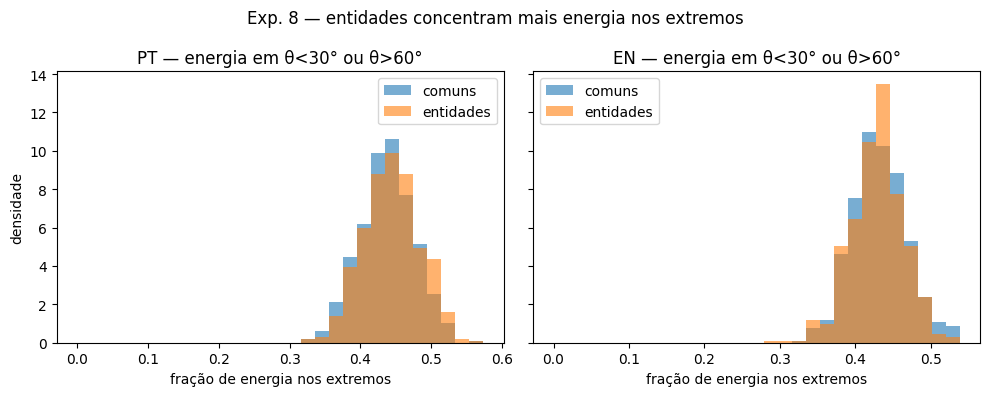

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, lang in zip(axes, ["pt", "en"]):
    e = res_main[lang]["ent"]["_raw"][0]
    c = res_main[lang]["com"]["_raw"][0]
    bins = np.linspace(0, max(e.max(), c.max()), 30)
    ax.hist(c, bins=bins, alpha=0.6, label="comuns", density=True)
    ax.hist(e, bins=bins, alpha=0.6, label="entidades", density=True)
    ax.set_title(f"{lang.upper()} — energia em θ<30° ou θ>60°")
    ax.set_xlabel("fração de energia nos extremos")
    ax.legend()
axes[0].set_ylabel("densidade")
fig.suptitle("Exp. 8 — entidades concentram mais energia nos extremos")
fig.tight_layout()
fig.savefig("_paper_exp78_fig8.png", dpi=150)

In [18]:
def clean(res):
    out = {}
    for lang, r in res.items():
        out[lang] = {g: {k: v for k, v in r[g].items() if k != "_raw"}
                     for g in ["ent", "com"]}
        out[lang]["welch_t_extreme_energy_ent_vs_com"] = \
            r["welch_t_extreme_energy_ent_vs_com"]
        out[lang]["welch_p"] = r["welch_p"]
    return out


exp8 = {
    "seed": SEED,
    "n_per_group": N,
    "extreme_definition_deg": {"low": EXT_LO, "high": EXT_HI},
    "n_extreme_directions": int(ext_mask.sum()),
    "main_sample": clean(res_main),
    "frequency_matched_sample": clean(res_matched),
    "top15_own_extreme": qual,
}
with open(RESULTS / "exp8.json", "w", encoding="utf-8") as fh:
    json.dump(exp8, fh, ensure_ascii=False, indent=2)
print("salvo:", RESULTS / "exp8.json")

salvo: C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp8.json


# Seção C — Experimentos 4, 6 e 9

# Experimentos 4, 6 e 9: proximidade de línguas, controle não-alinhado e diminutivos

Três experimentos complementares sobre o espectro de alinhamento GSVD
(ver `paper_common.py`):

4. **Largura da banda compartilhada × proximidade das línguas** — pares
   PT×EN, PT×ES, EN×ES e EN×DE, mesmo protocolo de frame; hipótese:
   línguas irmãs (PT×ES) têm banda compartilhada mais larga.
6. **Controle negativo** — embeddings CommonCrawl PT e EN treinados em
   espaços independentes (não-alinhados): o método deve detectar a
   ausência de estrutura compartilhada.
9. **Diminutivos em texto informal** — o offset -inho/-inha nos vetores
   CommonCrawl (via Procrustes para o espaço MUSE) vs Wikipédia.

In [19]:
import json
from pathlib import Path

import matplotlib

import matplotlib.pyplot as plt
import numpy as np

from gsvdlib import get_angles_C, get_most_similar_row_H, linear_cka
from paper_common import CACHE, RESULTS, Frame, build_frame, load_muse_pair

CC = Path.home() / ".gsvdlib" / "cc"
SEED = 1234


def load_words_X(path):
    d = np.load(path)
    return [str(w) for w in d["words"]], d["X"].astype(float)


def load_dict_txt(path):
    """Dicionário MUSE em texto: duas colunas separadas por espaço."""
    src, tgt = [], []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            parts = line.split()
            if len(parts) == 2:
                src.append(parts[0])
                tgt.append(parts[1])
    return src, tgt


def build_pairs_generic(words_a, words_b, dict_a, dict_b):
    """Mesma filtragem de build_pairs, para qualquer par de vocabulários.

    dict_a[i] traduz dict_b[i]; devolve pares (w_a, w_b) usáveis.
    """
    idx_a = {w: i for i, w in enumerate(words_a)}
    idx_b = {w: i for i, w in enumerate(words_b)}
    pairs, seen_a, seen_b = [], set(), set()
    for wa, wb in zip(dict_a, dict_b):
        if (wa in idx_a and wb in idx_b
                and wa.isalpha() and wb.isalpha()
                and len(wa) > 2 and len(wb) > 2
                and wa != wb
                and wa not in seen_a and wb not in seen_b):
            pairs.append((wa, wb))
            seen_a.add(wa)
            seen_b.add(wb)
    return pairs, idx_a, idx_b


def frame_means(A_feat, B_feat, n_A=900, n_B=800, seed=SEED):
    """Reproduz a amostragem de build_frame e devolve as médias da base."""
    rng = np.random.default_rng(seed)
    mA = A_feat[:, rng.permutation(A_feat.shape[1])[:n_A]].mean(
        axis=1, keepdims=True)
    mB = B_feat[:, rng.permutation(B_feat.shape[1])[:n_B]].mean(
        axis=1, keepdims=True)
    return mA, mB


def pair_metrics(name, Xa, Xb, idx_a, idx_b, pairs, seed=SEED,
                 n_train=1200, n_test=400):
    """Protocolo padrão: frame 900/800 de 1200 pares + retrieval em 400.

    Retorna dict de métricas e também (g, angles) para uso posterior.
    """
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(pairs))
    train = [pairs[i] for i in order[:n_train]]
    test = [pairs[i] for i in order[n_train:n_train + n_test]]
    A_all = Xa[:, [idx_a[wa] for wa, _ in train]]
    B_all = Xb[:, [idx_b[wb] for _, wb in train]]
    g, A, B = build_frame(A_all, B_all, seed=seed)
    angles = get_angles_C(g.C)
    cka = linear_cka(A, B)
    band = float(np.mean(np.abs(angles - 45.0) <= 5.0))

    # retrieval de tradução: consulta lado A -> candidatos = os 400 do teste
    mA, mB = frame_means(A_all, B_all, seed=seed)
    Q = Xa[:, [idx_a[wa] for wa, _ in test]] - mA
    Cand = Xb[:, [idx_b[wb] for _, wb in test]] - mB
    Qn = Q / np.maximum(np.linalg.norm(Q, axis=0), 1e-12)
    Cn = Cand / np.maximum(np.linalg.norm(Cand, axis=0), 1e-12)
    p1 = float(np.mean(np.argmax(Qn.T @ Cn, axis=1) == np.arange(len(test))))

    out = {"n_pares_vocab": len(pairs), "cka": round(cka, 4),
           "std_theta": round(float(angles.std()), 3),
           "frac_banda_45pm5": round(band, 4), "P1_traducao": round(p1, 4)}
    print(f"{name:8s} pares={len(pairs):5d} CKA={cka:.3f} "
          f"std(θ)={angles.std():.2f}° banda={band:.3f} P@1={p1:.3f}")
    return out, g, angles

## Experimento 4 — Largura da banda compartilhada × proximidade das línguas

Quatro pares de línguas, todos com vetores fastText alinhados no espaço
MUSE multilíngue (wiki), mesmo protocolo: vocabulário pareado pelo
dicionário MUSE (filtragem idêntica a `build_pairs`), 1200 pares de
treino (semente 1234), frame 900/800 e métricas de largura de banda:

- **CKA linear** entre as matrizes centradas do frame;
- **desvio-padrão de θ** (espectro mais estreito ⇒ menos direções
  específicas de língua);
- **fração de direções com |θ−45°| ≤ 5°** (a banda compartilhada);
- **P@1 de tradução** em 400 pares held-out (cosseno, vetores
  centralizados com as médias da base do frame, candidatos = os 400).

**Hipótese**: PT×ES (línguas irmãs) tem banda mais larga que EN×DE, com
PT×EN e EN×ES intermediários. Os números são reportados como saírem.

In [20]:
pt_words, pt_X, en_words, en_X, dict_en, dict_pt = load_muse_pair()
es_words, es_X = load_words_X(CACHE / "wiki_multi_es_top20k.npz")
de_words, de_X = load_words_X(CACHE / "wiki_multi_de_top20k.npz")

d_pt_es = load_dict_txt(CACHE / "dict_pt-es.txt")   # pt -> es
d_en_es = load_dict_txt(CACHE / "dict_en-es.txt")   # en -> es
d_en_de = load_dict_txt(CACHE / "dict_en-de.txt")   # en -> de

lang_pairs = {
    "PTxEN": (pt_X, en_X, build_pairs_generic(pt_words, en_words,
                                              dict_pt, dict_en)),
    "PTxES": (pt_X, es_X, build_pairs_generic(pt_words, es_words,
                                              d_pt_es[0], d_pt_es[1])),
    "ENxES": (en_X, es_X, build_pairs_generic(en_words, es_words,
                                              d_en_es[0], d_en_es[1])),
    "ENxDE": (en_X, de_X, build_pairs_generic(en_words, de_words,
                                              d_en_de[0], d_en_de[1])),
}

exp4 = {}
angles_by_pair = {}
for name, (Xa, Xb, (pairs, idx_a, idx_b)) in lang_pairs.items():
    exp4[name], _, angles_by_pair[name] = pair_metrics(
        name, Xa, Xb, idx_a, idx_b, pairs)

PTxEN    pares= 8331 CKA=0.851 std(θ)=13.37° banda=0.240 P@1=0.892


PTxES    pares= 6636 CKA=0.872 std(θ)=13.48° banda=0.240 P@1=0.970


ENxES    pares= 8616 CKA=0.862 std(θ)=13.19° banda=0.243 P@1=0.880


ENxDE    pares= 7656 CKA=0.857 std(θ)=14.09° banda=0.220 P@1=0.800


### Tabela final (ordenada por fração na banda compartilhada)

par         CKA   std θ   banda    P@1
ENxES     0.862   13.19   0.243  0.880
PTxEN     0.851   13.37   0.240  0.892
PTxES     0.872   13.48   0.240  0.970
ENxDE     0.857   14.09   0.220  0.800
salvo: C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp4.json


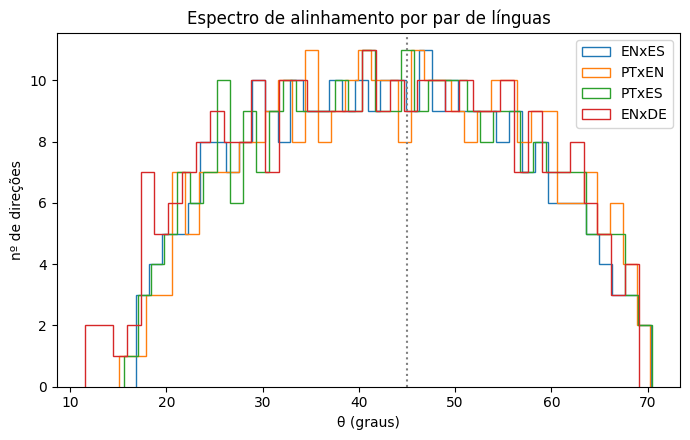

In [21]:
order4 = sorted(exp4, key=lambda k: -exp4[k]["frac_banda_45pm5"])
print(f"{'par':8s} {'CKA':>6s} {'std θ':>7s} {'banda':>7s} {'P@1':>6s}")
for k in order4:
    d = exp4[k]
    print(f"{k:8s} {d['cka']:6.3f} {d['std_theta']:7.2f} "
          f"{d['frac_banda_45pm5']:7.3f} {d['P1_traducao']:6.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
for k in order4:
    ax.hist(angles_by_pair[k], bins=40, histtype="step", label=k)
ax.axvline(45, color="gray", ls=":")
ax.set_xlabel("θ (graus)")
ax.set_ylabel("nº de direções")
ax.set_title("Espectro de alinhamento por par de línguas")
ax.legend()
fig.tight_layout()

exp4_out = {"ordenacao_por_banda": order4, "pares": exp4}
with open(RESULTS / "exp4.json", "w", encoding="utf-8") as fh:
    json.dump(exp4_out, fh, ensure_ascii=False, indent=2)
print("salvo:", RESULTS / "exp4.json")

## Experimento 6 — Controle: embeddings não-alinhados

Vetores fastText CommonCrawl PT e EN, treinados de forma independente
(nenhum alinhamento entre os espaços). Pareamos o vocabulário com o
mesmo dicionário MUSE do cache pt/en e aplicamos o protocolo do Exp. 4.
Adicionalmente, medimos a **coerência de tradução das direções**: para
60 direções amostradas uniformemente ao longo do espectro de θ, tomamos
as top-10 palavras de cada lado (cosseno contra o vocabulário) e a
fração de palavras EN cuja tradução aparece no top-10 PT.

**Predição**: sem alinhamento, o espectro perde sentido semântico — a
coerência fica perto de zero em toda parte e o P@1 desaba para o nível
do acaso (1/400 = 0.0025). Comparação: o par MUSE PT×EN alinhado.

CC(des)  pares= 6677 CKA=0.320 std(θ)=21.97° banda=0.130 P@1=0.007


Frame MUSE alinhado: 8331 pares


MUSE(al) pares= 8331 CKA=0.851 std(θ)=13.37° banda=0.240 P@1=0.892
coerência média das direções: CC=0.000 MUSE=0.167
salvo: C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp6.json


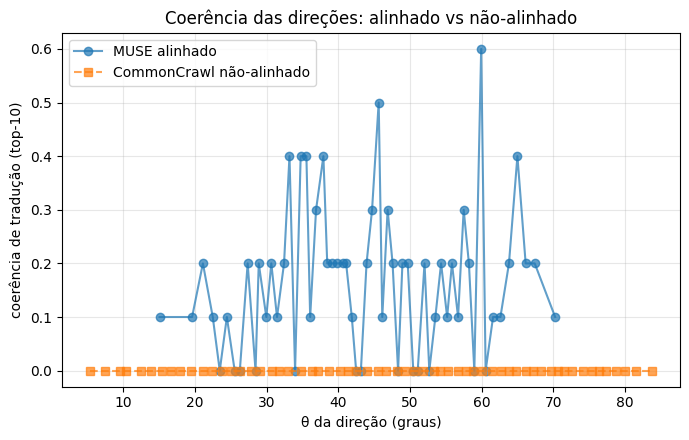

In [22]:
cc_pt_words, cc_pt_X = load_words_X(CC / "cc_pt_top20k.npz")
cc_en_words, cc_en_X = load_words_X(CC / "cc_en_top20k.npz")

# dicionário como dict de sets (para a coerência)
en2pt = {}
for e, p in zip(dict_en, dict_pt):
    en2pt.setdefault(e, set()).add(p)

cc_pairs, cc_idx_pt, cc_idx_en = build_pairs_generic(
    cc_pt_words, cc_en_words, dict_pt, dict_en)
exp6_cc, g_cc, ang_cc = pair_metrics(
    "CC(des)", cc_pt_X, cc_en_X, cc_idx_pt, cc_idx_en, cc_pairs)

f = Frame(seed=SEED)
print(f"Frame MUSE alinhado: {len(f.pairs)} pares")


def direction_coherence(g, angles, X_pt, words_pt, X_en, words_en,
                        n_dirs=60, k=10):
    """Coerência de tradução por direção, amostrada uniformemente em θ."""
    order = np.argsort(angles)
    sel = order[np.linspace(0, len(order) - 1, n_dirs).astype(int)]
    out = []
    for i in sel:
        d = g.H[i]
        sp = get_most_similar_row_H(d, X_pt.T)
        se = get_most_similar_row_H(d, X_en.T)
        top_pt = {words_pt[j] for j in np.argsort(-np.abs(sp))[:k]}
        top_en = [words_en[j] for j in np.argsort(-np.abs(se))[:k]]
        frac = sum(1 for e in top_en if en2pt.get(e, set()) & top_pt) / k
        out.append((float(angles[i]), frac))
    return out


coh_cc = direction_coherence(g_cc, ang_cc, cc_pt_X, cc_pt_words,
                             cc_en_X, cc_en_words)
coh_muse = direction_coherence(f.g, f.angles, f.pt_X, f.pt_words,
                               f.en_X, f.en_words)

# métricas do par alinhado no mesmo formato (frame padrão + retrieval)
exp6_muse, _, _ = pair_metrics(
    "MUSE(al)", f.pt_X, f.en_X, f.pt_idx, f.en_idx,
    [(p, e) for e, p in f.pairs])

coh_cc_mean = float(np.mean([c for _, c in coh_cc]))
coh_muse_mean = float(np.mean([c for _, c in coh_muse]))
print(f"coerência média das direções: CC={coh_cc_mean:.3f} "
      f"MUSE={coh_muse_mean:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(*zip(*coh_muse), "o-", label="MUSE alinhado", alpha=0.7)
ax.plot(*zip(*coh_cc), "s--", label="CommonCrawl não-alinhado", alpha=0.7)
ax.set_xlabel("θ da direção (graus)")
ax.set_ylabel("coerência de tradução (top-10)")
ax.set_title("Coerência das direções: alinhado vs não-alinhado")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

exp6_out = {
    "nao_alinhado_cc": {**exp6_cc, "coerencia_media": round(coh_cc_mean, 4)},
    "alinhado_muse": {**exp6_muse,
                      "coerencia_media": round(coh_muse_mean, 4)},
    "coerencia_por_direcao_cc": [[round(a, 2), c] for a, c in coh_cc],
    "coerencia_por_direcao_muse": [[round(a, 2), c] for a, c in coh_muse],
    "acaso_P1": 1.0 / 400,
}
with open(RESULTS / "exp6.json", "w", encoding="utf-8") as fh:
    json.dump(exp6_out, fh, ensure_ascii=False, indent=2)
print("salvo:", RESULTS / "exp6.json")

## Experimento 9 — Diminutivos em texto informal via Procrustes

Nos vetores Wikipédia, o offset de diminutivo (-inho/-inha) tem coerência
interna fraca (~0.14). Hipótese: no CommonCrawl (texto informal) a
morfologia é produtiva e o diminutivo vira direção linear.

**(a)** Alinhamos cc_pt ao espaço MUSE wiki.pt por Procrustes ortogonal:
vocabulário comum entre cc_pt top-20k e o lado PT do cache MUSE,
`W = U Vᵀ` da SVD de `B Aᵀ` (A=cc, B=muse, vetores como estão), que
minimiza `‖W A − B‖_F` com W ortogonal. Validação em palavras held-out.

In [23]:
cc100_words, cc100_X = load_words_X(CC / "cc_pt_top100k.npz")
wiki100_words, wiki100_X = load_words_X(CACHE / "muse_pt_top100k.npz")
cc100_idx = {w: i for i, w in enumerate(cc100_words)}
wiki100_idx = {w: i for i, w in enumerate(wiki100_words)}

muse_pt_idx = {w: i for i, w in enumerate(pt_words)}
common = [w for w in cc_pt_words if w in muse_pt_idx]
rng9 = np.random.default_rng(SEED)
perm = rng9.permutation(len(common))
held = [common[i] for i in perm[:1000]]
train_w = [common[i] for i in perm[1000:]]
print(f"vocab comum cc20k ∩ muse-pt: {len(common)} "
      f"(treino={len(train_w)}, held-out={len(held)})")

cc20_idx = {w: i for i, w in enumerate(cc_pt_words)}
A_tr = cc_pt_X[:, [cc20_idx[w] for w in train_w]]
B_tr = pt_X[:, [muse_pt_idx[w] for w in train_w]]
U, _, Vt = np.linalg.svd(B_tr @ A_tr.T)
W = U @ Vt

A_ho = cc_pt_X[:, [cc20_idx[w] for w in held]]
B_ho = pt_X[:, [muse_pt_idx[w] for w in held]]
WA = W @ A_ho
cos_ho = np.sum(WA * B_ho, axis=0) / (
    np.linalg.norm(WA, axis=0) * np.linalg.norm(B_ho, axis=0))
proc_val = float(cos_ho.mean())
print(f"Procrustes: cosseno médio held-out = {proc_val:.3f}")

vocab comum cc20k ∩ muse-pt: 10572 (treino=9572, held-out=1000)
Procrustes: cosseno médio held-out = 0.724


**(b)** Pares de diminutivos: offsets `v(diminutivo) − v(base)` calculados
**no espaço cc** (top-100k, sem projetar) e coerência interna (cosseno
médio par a par dos offsets). Comparação: a mesma lista nos vetores
Wikipédia (muse_pt_top100k) e um baseline de offsets de pares aleatórios.

In [24]:
DIM_PAIRS = [("casa", "casinha"), ("gato", "gatinho"), ("pouco", "pouquinho"),
             ("amigo", "amiguinho"), ("café", "cafezinho"),
             ("beijo", "beijinho"), ("pedaço", "pedacinho"),
             ("cidade", "cidadezinha"), ("irmã", "irmãzinha"),
             ("cavalo", "cavalinho"), ("bola", "bolinha"),
             ("carro", "carrinho"), ("barco", "barquinho"),
             ("igreja", "igrejinha"), ("fazenda", "fazendinha"),
             ("escola", "escolinha"), ("praça", "pracinha"),
             ("neto", "netinho"), ("irmão", "irmãozinho"),
             ("velho", "velhinho"), ("baixo", "baixinho"),
             ("bonito", "bonitinho"), ("filho", "filhinho"),
             ("mãe", "mãezinha"), ("pai", "paizinho"), ("hora", "horinha"),
             ("jeito", "jeitinho"), ("coisa", "coisinha"),
             ("festa", "festinha"), ("presente", "presentinho")]


def offsets_in(pairs, X, idx):
    found, offs = [], []
    for base, dim in pairs:
        if base in idx and dim in idx:
            found.append((base, dim))
            offs.append(X[:, idx[dim]] - X[:, idx[base]])
    return found, np.array(offs).T  # (dim x n)


def mean_pairwise_cos(O):
    On = O / np.maximum(np.linalg.norm(O, axis=0), 1e-12)
    G = On.T @ On
    n = G.shape[0]
    return float((G.sum() - n) / (n * (n - 1)))


found_cc, off_cc = offsets_in(DIM_PAIRS, cc100_X, cc100_idx)
found_wk, off_wk = offsets_in(DIM_PAIRS, wiki100_X, wiki100_idx)
coh_cc9 = mean_pairwise_cos(off_cc)
coh_wk9 = mean_pairwise_cos(off_wk)

# baseline: offsets de pares aleatórios do vocabulário cc (mesmo n)
alpha_ws = [w for w in cc100_words[:20000] if w.isalpha() and len(w) > 2]
rb = np.random.default_rng(SEED)
rand_pairs = [(alpha_ws[i], alpha_ws[j]) for i, j in
              rb.choice(len(alpha_ws), (len(found_cc), 2), replace=False)]
_, off_rand = offsets_in(rand_pairs, cc100_X, cc100_idx)
coh_rand = mean_pairwise_cos(off_rand)

print(f"pares no cc100k: {len(found_cc)}/{len(DIM_PAIRS)}; "
      f"no wiki100k: {len(found_wk)}/{len(DIM_PAIRS)}")
print(f"coerência interna: cc={coh_cc9:.3f} wiki={coh_wk9:.3f} "
      f"baseline aleatório={coh_rand:.3f}")

pares no cc100k: 28/30; no wiki100k: 24/30
coerência interna: cc=0.163 wiki=0.142 baseline aleatório=-0.003


**(c)** Projetamos os offsets cc para o espaço MUSE via `W` e medimos θ
no frame padrão (`Frame().theta`). Referências: θ médio dos offsets
wiki (~43.4°) e das palavras PT comuns (~41.6°). Reportamos como sair.

θ médio: diminutivos cc-projetados=42.84° wiki=43.26° palavras PT comuns=42.21°
salvo: C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp9.json


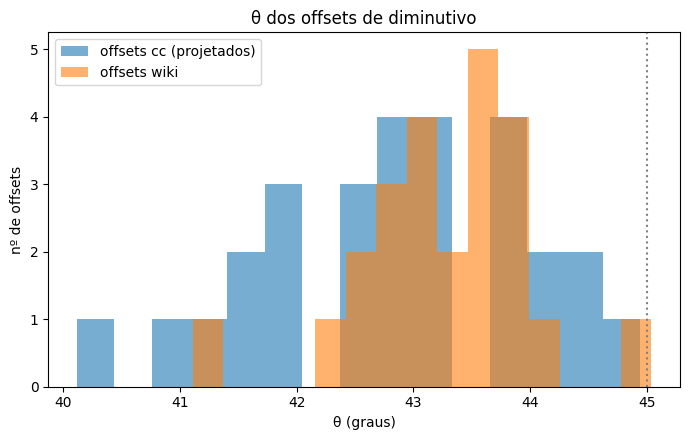

In [25]:
theta_cc = f.theta(W @ off_cc)
theta_wk = f.theta(off_wk)
# referência: θ de palavras PT comuns (200 palavras dos pares de treino)
ref_ws = [p for _, p in f.pairs[:200]]
theta_ref = f.theta(f.pt_X[:, [f.pt_idx[w] for w in ref_ws]])
print(f"θ médio: diminutivos cc-projetados={theta_cc.mean():.2f}° "
      f"wiki={theta_wk.mean():.2f}° palavras PT comuns={theta_ref.mean():.2f}°")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(theta_cc, bins=15, alpha=0.6, label="offsets cc (projetados)")
ax.hist(theta_wk, bins=15, alpha=0.6, label="offsets wiki")
ax.axvline(45, color="gray", ls=":")
ax.set_xlabel("θ (graus)")
ax.set_ylabel("nº de offsets")
ax.set_title("θ dos offsets de diminutivo")
ax.legend()
fig.tight_layout()

exp9_out = {
    "procrustes": {"n_vocab_comum": len(common), "n_treino": len(train_w),
                   "n_heldout": len(held),
                   "cos_medio_heldout": round(proc_val, 4)},
    "n_pares_cc100k": len(found_cc), "n_pares_wiki100k": len(found_wk),
    "coerencia_offsets": {"cc": round(coh_cc9, 4), "wiki": round(coh_wk9, 4),
                          "baseline_aleatorio": round(coh_rand, 4)},
    "theta_medio": {"diminutivos_cc_projetados": round(float(theta_cc.mean()), 2),
                    "diminutivos_wiki": round(float(theta_wk.mean()), 2),
                    "palavras_pt_comuns": round(float(theta_ref.mean()), 2)},
    "theta_cc_por_par": {f"{b}->{d}": round(float(t), 2)
                         for (b, d), t in zip(found_cc, theta_cc)},
}
with open(RESULTS / "exp9.json", "w", encoding="utf-8") as fh:
    json.dump(exp9_out, fh, ensure_ascii=False, indent=2)
print("salvo:", RESULTS / "exp9.json")

**Leitura**: o Exp. 4 testa se a banda compartilhada acompanha a
proximidade tipológica; o Exp. 6 mostra o que acontece quando não há
estrutura compartilhada nenhuma (controle negativo); o Exp. 9 verifica
se a morfologia produtiva do diminutivo emerge como direção linear em
texto informal. Os números salvos em `paper_results/exp{4,6,9}.json`
valem como saíram, confirmem ou não as hipóteses.

# Seção D — Experimento 5 (mBERT)

# Experimento 5 — Onde no mBERT o espaço é mais interlingual?

Extraímos embeddings estáticos (palavra isolada, média dos subtokens) de
**todas as 13 camadas** do `bert-base-multilingual-cased` para os mesmos
pares PT/EN usados no frame MUSE de `paper_common`. Para cada camada L
montamos um frame GSVD conjunto (`build_frame`) e medimos:

- **CKA linear** entre as matrizes centradas A (PT) e B (EN);
- o espectro de ângulos θ (`get_angles_C`): desvio-padrão (largura) e
  fração de direções na **banda compartilhada** |θ−45°| ≤ 5°;
- **P@1 de retrieval de tradução** (400 pares de teste, cosseno no espaço
  completo da camada, centrado com as médias da base).

Comparamos com o baseline MUSE (frame estático de `paper_common`).
A literatura sugere que as camadas intermediárias (~8) são as mais
"interlinguais".

In [26]:
import json
from pathlib import Path

import numpy as np

from gsvdlib import get_angles_C, linear_cka
from paper_common import Frame, build_frame, RESULTS

MBERT_CACHE = Path.home() / ".gsvdlib" / "mbert"
MBERT_CACHE.mkdir(parents=True, exist_ok=True)
CACHE_NPZ = MBERT_CACHE / "mbert_pairs_layers.npz"

N_BASE, N_TEST = 1200, 400
SEED = 1234

## Palavras pareadas

Reconstruímos a mesma permutação (semente 1234) usada dentro de `Frame`
para recuperar os 1200 pares da base; os 400 de teste vêm de
`f.test_pairs`. Cada par é (en, pt).

In [27]:
f = Frame()
order = np.random.default_rng(SEED).permutation(len(f.pairs))
base_pairs = [f.pairs[i] for i in order[:N_BASE]]
assert f.test_pairs[0] == f.pairs[order[N_BASE]]  # sanidade: mesma ordem
test_pairs = f.test_pairs[:N_TEST]

pairs_all = base_pairs + test_pairs
en_words = [e for e, p in pairs_all]
pt_words = [p for e, p in pairs_all]

## Extração mBERT (com cache)

Cada palavra é tokenizada isolada (sem contexto); para cada camada 0..12
tiramos a média dos hidden states dos subtokens reais (sem [CLS]/[SEP]).
Resultado: arrays (13, 768, 1600) por língua, salvos em um único npz.

In [28]:
def extract_mbert(words, tokenizer, model, batch_size=64):
    import torch
    n = len(words)
    out = np.zeros((13, 768, n), dtype=np.float32)
    with torch.no_grad():
        for s in range(0, n, batch_size):
            batch = words[s:s + batch_size]
            enc = tokenizer(batch, return_tensors="pt", padding=True)
            hs = model(**enc, output_hidden_states=True).hidden_states
            # máscara dos subtokens reais: attention_mask sem [CLS]/[SEP]
            mask = enc["attention_mask"].clone()
            mask[:, 0] = 0                                   # [CLS]
            last = enc["attention_mask"].sum(dim=1) - 1      # posição do [SEP]
            mask[torch.arange(len(batch)), last] = 0
            m = mask.unsqueeze(-1).float()
            denom = m.sum(dim=1).clamp(min=1.0)              # (b, 1)
            for L in range(13):
                mean = (hs[L] * m).sum(dim=1) / denom        # (b, 768)
                out[L, :, s:s + len(batch)] = mean.T.numpy()
    return out


if CACHE_NPZ.exists():
    d = np.load(CACHE_NPZ, allow_pickle=False)
    pt_H, en_H = d["pt"], d["en"]
    assert list(d["pt_words"]) == pt_words and list(d["en_words"]) == en_words
    print("cache carregado:", CACHE_NPZ)
else:
    import torch
    from transformers import AutoModel, AutoTokenizer

    name = "bert-base-multilingual-cased"
    tokenizer = AutoTokenizer.from_pretrained(name)
    model = AutoModel.from_pretrained(name)
    model.eval()
    print("extraindo PT...")
    pt_H = extract_mbert(pt_words, tokenizer, model)
    print("extraindo EN...")
    en_H = extract_mbert(en_words, tokenizer, model)
    np.savez_compressed(CACHE_NPZ, pt=pt_H, en=en_H,
                        pt_words=np.array(pt_words), en_words=np.array(en_words))
    print("cache salvo:", CACHE_NPZ)

cache carregado: C:\Users\Eduarda\.gsvdlib\mbert\mbert_pairs_layers.npz


## Métricas por camada

Para cada camada L: frame GSVD com 900/800 amostras da base (mesma
semente do resto do paper), CKA, espectro de θ e retrieval P@1 nos 400
pares de teste (centrados com as médias da base, cosseno entre os 400
candidatos EN).

In [29]:
def p_at_1(PT_base, EN_base, PT_test, EN_test):
    """Retrieval de tradução por cosseno no espaço completo."""
    Pt = PT_test - PT_base.mean(axis=1, keepdims=True)
    Et = EN_test - EN_base.mean(axis=1, keepdims=True)
    Pt = Pt / np.maximum(np.linalg.norm(Pt, axis=0), 1e-12)
    Et = Et / np.maximum(np.linalg.norm(Et, axis=0), 1e-12)
    pred = np.argmax(Pt.T @ Et, axis=1)
    return float(np.mean(pred == np.arange(Pt.shape[1])))


def layer_metrics(PT_L, EN_L):
    PT_base, PT_test = PT_L[:, :N_BASE], PT_L[:, N_BASE:]
    EN_base, EN_test = EN_L[:, :N_BASE], EN_L[:, N_BASE:]
    g, A, B = build_frame(PT_base, EN_base, n_A=900, n_B=800, seed=SEED)
    th = get_angles_C(g.C)
    return {
        "cka": linear_cka(A, B),
        "std_theta": float(np.std(th)),
        "frac_shared": float(np.mean(np.abs(th - 45.0) <= 5.0)),
        "p_at_1": p_at_1(PT_base, EN_base, PT_test, EN_test),
    }


rows = []
for L in range(13):
    m = layer_metrics(pt_H[L].astype(float), en_H[L].astype(float))
    m["layer"] = L
    rows.append(m)
    print(f"camada {L:2d}: cka={m['cka']:.3f}  std={m['std_theta']:.2f}  "
          f"frac45={m['frac_shared']:.3f}  P@1={m['p_at_1']:.3f}")

camada  0: cka=0.609  std=25.85  frac45=0.104  P@1=0.482


camada  1: cka=0.641  std=25.41  frac45=0.108  P@1=0.487


camada  2: cka=0.688  std=25.33  frac45=0.107  P@1=0.492


camada  3: cka=0.735  std=25.23  frac45=0.109  P@1=0.507


camada  4: cka=0.767  std=25.14  frac45=0.113  P@1=0.502


...

camada  8: cka=0.820  std=25.13  frac45=0.112  P@1=0.530


camada  9: cka=0.833  std=25.14  frac45=0.108  P@1=0.475


camada 10: cka=0.832  std=25.26  frac45=0.112  P@1=0.472


camada 11: cka=0.790  std=25.50  frac45=0.104  P@1=0.480


camada 12: cka=0.744  std=25.85  frac45=0.104  P@1=0.492


## Baseline MUSE

Mesmas métricas no frame estático de `paper_common`: θ do frame pronto,
CKA em `f.A`/`f.B`, e P@1 nos mesmos 400 pares de teste sobre os vetores
MUSE (base = as mesmas 1200 palavras).

In [30]:
PT_muse_base = f.pt_X[:, [f.pt_idx[p] for e, p in base_pairs]]
EN_muse_base = f.en_X[:, [f.en_idx[e] for e, p in base_pairs]]
PT_muse_test = np.stack([f.v_pt(p) for e, p in test_pairs], axis=1)
EN_muse_test = np.stack([f.v_en(e) for e, p in test_pairs], axis=1)

muse = {
    "cka": linear_cka(f.A, f.B),
    "std_theta": float(np.std(f.angles)),
    "frac_shared": float(np.mean(np.abs(f.angles - 45.0) <= 5.0)),
    "p_at_1": p_at_1(PT_muse_base, EN_muse_base, PT_muse_test, EN_muse_test),
}
print("MUSE:", muse)

MUSE: {'cka': 0.8511759217930225, 'std_theta': 13.369392948879282, 'frac_shared': 0.24, 'p_at_1': 0.8925}


## Figura — frac_shared e P@1 por camada, com o baseline MUSE

figura salva em C:\Users\Eduarda\Desktop\UFRJ\Pesquisa\tcc\gsvdlib\examples\paper_results\exp5_layers.png


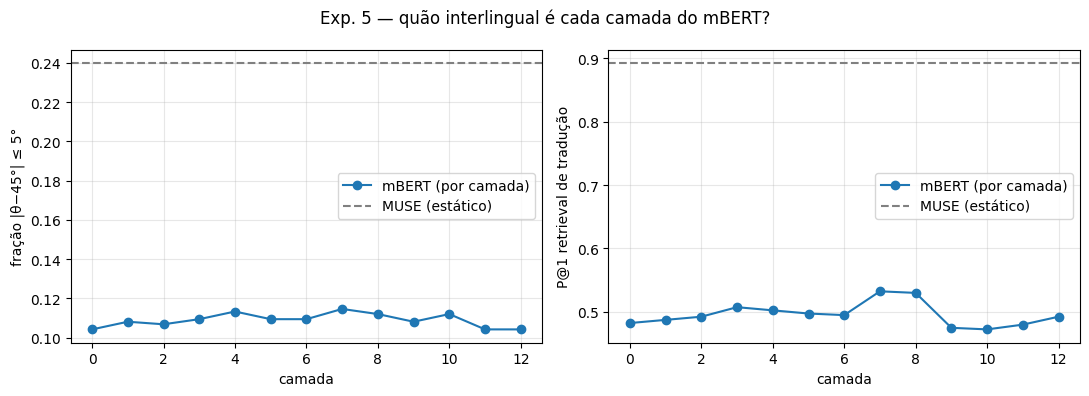

In [31]:
import matplotlib
import matplotlib.pyplot as plt

layers = [r["layer"] for r in rows]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, label in [(axes[0], "frac_shared", "fração |θ−45°| ≤ 5°"),
                       (axes[1], "p_at_1", "P@1 retrieval de tradução")]:
    ax.plot(layers, [r[key] for r in rows], "o-", label="mBERT (por camada)")
    ax.axhline(muse[key], color="gray", ls="--", label="MUSE (estático)")
    ax.set_xlabel("camada")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle("Exp. 5 — quão interlingual é cada camada do mBERT?")
fig.tight_layout()
fig.savefig(RESULTS / "exp5_layers.png", dpi=150)
print("figura salva em", RESULTS / "exp5_layers.png")

## Salvar resultados

In [32]:
best_frac = max(rows, key=lambda r: r["frac_shared"])["layer"]
best_p1 = max(rows, key=lambda r: r["p_at_1"])["layer"]
out = {"layers": rows, "muse_baseline": muse,
       "best_layer_frac_shared": best_frac, "best_layer_p_at_1": best_p1}
with open(RESULTS / "exp5.json", "w", encoding="utf-8") as fh:
    json.dump(out, fh, indent=2, ensure_ascii=False)
print("exp5.json salvo. melhor camada (frac_shared):", best_frac,
      "| melhor camada (P@1):", best_p1)

exp5.json salvo. melhor camada (frac_shared): 7 | melhor camada (P@1): 7
